In [1]:
!pip install tensorflow

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.datasets import fashion_mnist, mnist

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns


tf.keras.utils.disable_interactive_logging()

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
(x_train_fnn, y_train_fnn), (x_test_fnn, y_test_fnn) = fashion_mnist.load_data()


print("Training Data Shape:", x_train_fnn.shape)
print("Testing Data Shape:", x_test_fnn.shape)

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


In [7]:
x_train_fnn_flat = x_train_fnn.reshape(
    -1,
    28*28
)

x_test_fnn_flat = x_test_fnn.reshape(
    -1,
    28*28
)


x_train_fnn_norm = x_train_fnn_flat / 255.0

x_test_fnn_norm = x_test_fnn_flat / 255.0


print(x_train_fnn_norm.shape)
print(x_test_fnn_norm.shape)

(60000, 784)
(10000, 784)


In [9]:
model_fnn = keras.Sequential([

    layers.Dense(
        128,
        activation='relu',
        input_shape=(784,)
    ),

    layers.Dropout(0.2),

    layers.Dense(
        64,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )

])


model_fnn.summary()

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model_fnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("FNN Model Compiled")

FNN Model Compiled


In [13]:
history_fnn = model_fnn.fit(
    x_train_fnn_norm,
    y_train_fnn,
    epochs=10,
    validation_split=0.1
)

In [14]:
loss_fnn, accuracy_fnn = model_fnn.evaluate(
    x_test_fnn_norm,
    y_test_fnn
)


print("FNN Test Loss:", loss_fnn)
print("FNN Test Accuracy:", accuracy_fnn)

FNN Test Loss: 0.33961161971092224
FNN Test Accuracy: 0.8830000162124634


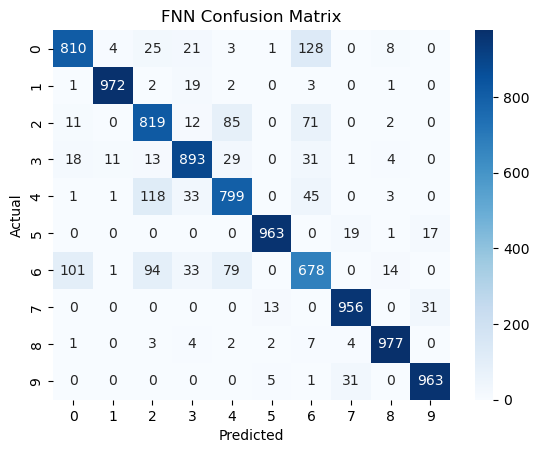

In [15]:
y_pred_fnn = np.argmax(
    model_fnn.predict(x_test_fnn_norm),
    axis=1
)


cm_fnn = confusion_matrix(
    y_test_fnn,
    y_pred_fnn
)


sns.heatmap(
    cm_fnn,
    annot=True,
    fmt='d',
    cmap='Blues'
)


plt.title("FNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
(x_train_cnn, y_train_cnn), (x_test_cnn, y_test_cnn) = mnist.load_data()


print(x_train_cnn.shape)
print(x_test_cnn.shape)

(60000, 28, 28)
(10000, 28, 28)


In [21]:
x_train_cnn = x_train_cnn.reshape(
    -1,
    28,
    28,
    1
)

x_test_cnn = x_test_cnn.reshape(
    -1,
    28,
    28,
    1
)


x_train_cnn = x_train_cnn / 255.0

x_test_cnn = x_test_cnn / 255.0


print(x_train_cnn.shape)

(60000, 28, 28, 1)


In [23]:
model_cnn = keras.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D(
        (2,2)
    ),


    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),


    layers.MaxPooling2D(
        (2,2)
    ),


    layers.Flatten(),


    layers.Dense(
        128,
        activation='relu'
    ),


    layers.Dropout(0.5),


    layers.Dense(
        10,
        activation='softmax'
    )

])


model_cnn.summary()

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model Compiled")

CNN Model Compiled


In [27]:
history_cnn = model_cnn.fit(
    x_train_cnn,
    y_train_cnn,
    epochs=10,
    validation_split=0.1
)

In [28]:
loss_cnn, accuracy_cnn = model_cnn.evaluate(
    x_test_cnn,
    y_test_cnn
)


print("CNN Test Loss:", loss_cnn)
print("CNN Test Accuracy:", accuracy_cnn)

CNN Test Loss: 0.023375188931822777
CNN Test Accuracy: 0.9936000108718872


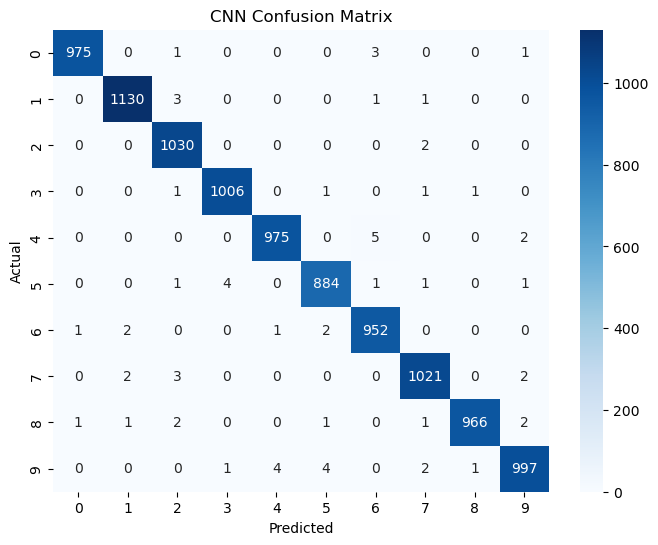

In [29]:
y_pred_cnn = np.argmax(
    model_cnn.predict(x_test_cnn),
    axis=1
)


cm_cnn = confusion_matrix(
    y_test_cnn,
    y_pred_cnn
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Blues'
)


plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

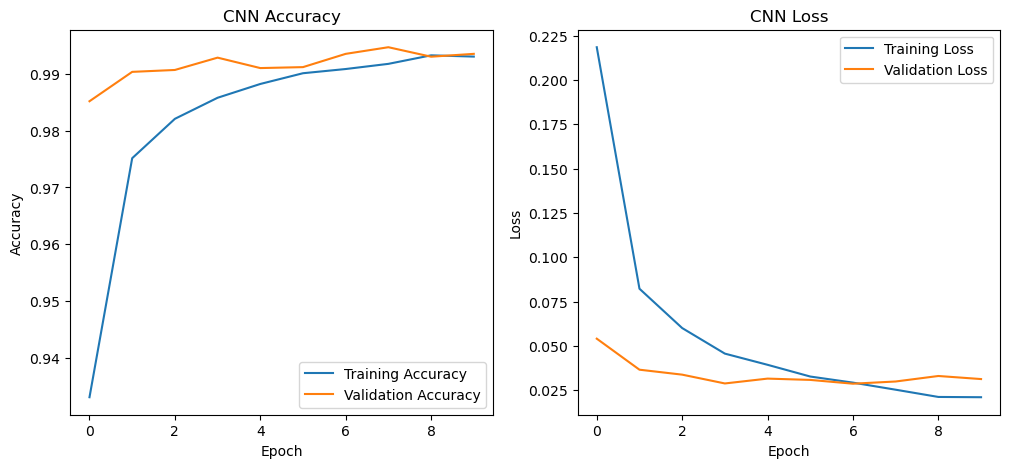

In [30]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

plt.plot(
    history_cnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)


plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()



plt.subplot(1,2,2)


plt.plot(
    history_cnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss'
)


plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.show()